In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler


In [2]:
import pandas as pd


train = pd.read_csv('data/train_set_all.csv')
pred = pd.read_csv('data/compound_new_structural.csv')

X_train = train.iloc[:, 1:].values   
X_pred = pred.iloc[:, 1:].values      



In [3]:
from sklearn.preprocessing import StandardScaler
import numpy as np

X_all = np.vstack((X_train, X_pred))
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_all)

n_train = X_train.shape[0]
X_train_scaled = X_scaled[:n_train]
X_pred_scaled = X_scaled[n_train:]


In [12]:
import umap.umap_ as umap

umap_model = umap.UMAP(n_neighbors=50, min_dist=0.001, metric='cosine', random_state=68)
X_pred_umap = umap_model.fit_transform(X_pred_scaled)

X_train_umap = umap_model.transform(X_train_scaled)


D:\app\miniconda\envs\py310\lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
D:\app\miniconda\envs\py310\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
D:\app\miniconda\envs\py310\lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


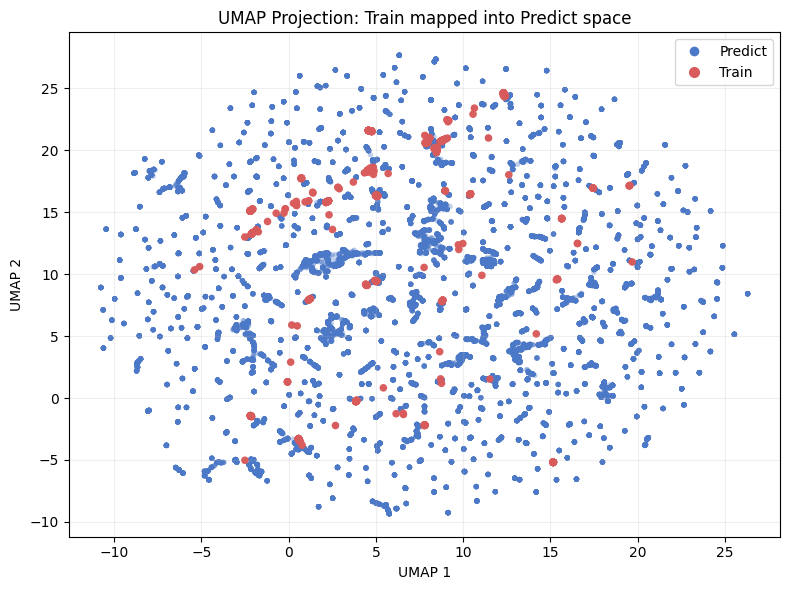

In [8]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

C_TRAIN = "#D95B5B"  
C_PRED  = "#4C79C7" 

plt.figure(figsize=(8, 6))

plt.scatter(
    X_pred_umap[:, 0], X_pred_umap[:, 1],
    c=C_PRED, s=15, marker='o', alpha=0.35,
    edgecolor='none', label='Predict', zorder=1
)

plt.scatter(
    X_train_umap[:, 0], X_train_umap[:, 1],
    c=C_TRAIN, s=30, marker='o', alpha=0.98,
    edgecolor='none', label='Train', zorder=3
)

plt.xlabel("UMAP 1"); plt.ylabel("UMAP 2")
plt.title("UMAP Projection: Train mapped into Predict space")

handles = [
    Line2D([0],[0], marker='o', linestyle='None', markerfacecolor=C_PRED,  markeredgecolor='none', label='Predict', markersize=7),
    Line2D([0],[0], marker='o', linestyle='None', markerfacecolor=C_TRAIN, markeredgecolor='none', label='Train',   markersize=8),
]
plt.legend(handles=handles, loc="upper right", frameon=True)

plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()


In [9]:
# —— 导出 UMAP 坐标到 CSV，便于在 Origin 里作图 ——
import pandas as pd
import numpy as np

def get_ids(df):
    col0 = df.columns[0]
    return df[col0].astype(str)

train_ids = get_ids(train)
pred_ids  = get_ids(pred)

df_train_out = pd.DataFrame({
    "id":    train_ids.values,
    "UMAP1": X_train_umap[:, 0],
    "UMAP2": X_train_umap[:, 1],
    "set":   "Train",
})

df_pred_out = pd.DataFrame({
    "id":    pred_ids.values,
    "UMAP1": X_pred_umap[:, 0],
    "UMAP2": X_pred_umap[:, 1],
    "set":   "Predict",
})


df_train_out.to_csv("result/umap_coords_train_1.csv", index=False, float_format="%.6f")
df_pred_out.to_csv("result/umap_coords_predict_1.csv", index=False, float_format="%.6f")


df_all = pd.concat([df_train_out, df_pred_out], axis=0, ignore_index=True)
df_all.to_csv("result/umap_coords_all_1.csv", index=False, float_format="%.6f")

print("Saved")


Saved
